In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import re
import stan
import seaborn as sns
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load territory data
terr = pd.read_csv('processed_data/territory_data.csv')
ndvi = pd.read_csv('rawdata/Velavadar/ndvi.csv')

## Parse dates
terr['date'] = pd.to_datetime(terr['Date'], format='%Y-%b')
ndvi['date'] = pd.to_datetime(ndvi['Label'])

## Pivot to wide so we have one row per timepoint
## Get territory counts on each lek
df = (terr.pivot_table(index='date', columns='Lek', values='count', aggfunc='sum').sort_index()
        .rename(columns={1: 'N1', 2: 'N2'}).rename_axis(None, axis=1).reset_index().sort_values('date'))


## Add columns for the total number of territories and the proportion of territories on site 1 and site 2
df['N'] = df['N1'] + df['N2']
df['p1'] = df['N1']/df['N']
df['p2'] = df['N2']/df['N']
df['logN'] = np.log(df['N'])

## Merge NDVI information into this dataframe
df = df.merge(ndvi, on='date', how='left').drop(columns=['Label']).rename(columns={'Polygon 1': 'NDVI1', 'Polygon 2': 'NDVI2'})
df['dNDVI'] = df['NDVI2'] - df['NDVI1']
df.head()

,date,N1,N2,N,p1,p2,logN,NDVI1,NDVI2,dNDVI
0,2013-12-01,43,0,43,1.000000,0.000000,3.761200,0.307,0.315,0.008
1,2014-02-01,73,25,98,0.744898,0.255102,4.584967,0.227,0.238,0.011
2,2014-10-01,37,1,38,0.973684,0.026316,3.637586,0.371,0.386,0.015
3,2015-05-01,83,76,159,0.522013,0.477987,5.068904,0.173,0.170,-0.003
4,2015-11-01,49,19,68,0.720588,0.279412,4.219508,0.279,0.295,0.016


In [4]:
## Colour palettes
fill_cols = {'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

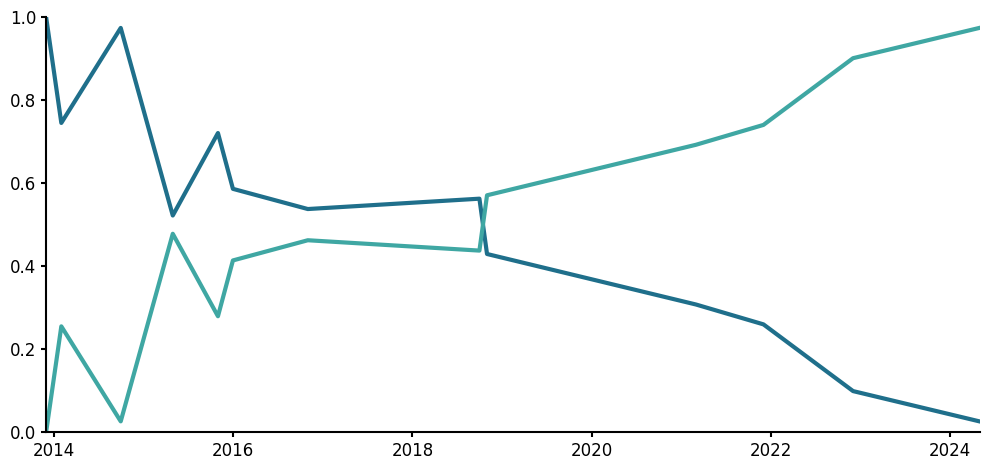

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))

## Plot the two sites over time
ax.plot(df['date'], df['p1'], color=fill_cols['Velavadar Lek 1'], linewidth=3)
ax.plot(df['date'], df['p2'], color=fill_cols['Velavadar Lek 2'], linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel('', fontsize=14)
ax.set_xlabel('', fontsize=14)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.margins(x=0)
ax.set_ylim(0, 1)
ax.tick_params(axis='both', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'transition_data.png', dpi=300)

In [6]:
## Month look-up chart
month_lookup = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6, 
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}

## Parse date from file label
def parse_yyMMM(label):
    '''
    Convert labels like '13DEC' or '14FEB' into a pandas Timestamp
    '''
    m = re.match(r'^(\d{2})([A-Z]{3})$', label.upper())
    if m is None:
        raise ValueError(f'Unrecognized date label: {label}')
        
    yy = int(m.group(1))
    mon = month_lookup[m.group(2)]
    return pd.Timestamp(datetime(2000 + yy, mon, 1))

def read_lek_csv(date_dir, date_label, lek_num):
    '''
    Read csv without raising an error if csv was not found
    '''
    f = date_dir / f'{date_label}_LEK{lek_num}.csv'
    if not f.exists():
        return None
    
    df = pd.read_csv(f)
    
    return df[['latitude', 'longitude']].copy()

In [7]:
# Discover date folders
base_dir = Path('rawdata/Velavadar')
data_dirs = sorted([p for p in base_dir.glob('*_COORDINATES') if p.is_dir()])

# Collect per-date point sets
date_records = []
for d in data_dirs:
    date_label = d.name.replace('_COORDINATES', '').upper()
    date_ts = parse_yyMMM(date_label)

    df1 = read_lek_csv(d, date_label, 1)
    df2 = read_lek_csv(d, date_label, 2)

    date_records.append({'date_label': date_label, 'date': date_ts, 'lek1': df1, 'lek2': df2})

date_records = sorted(date_records, key=lambda r: r['date'])

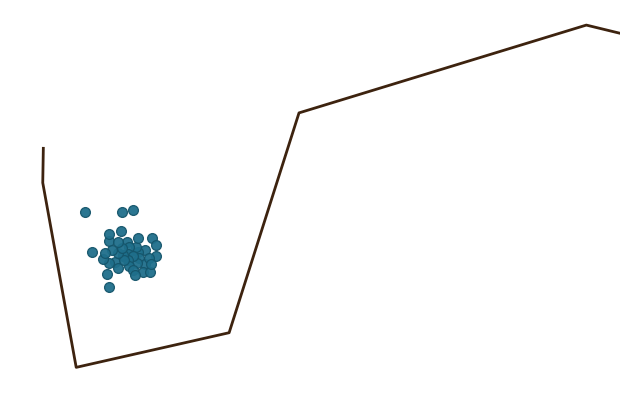

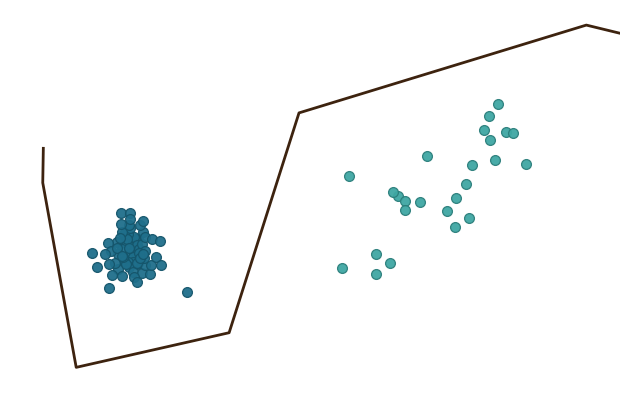

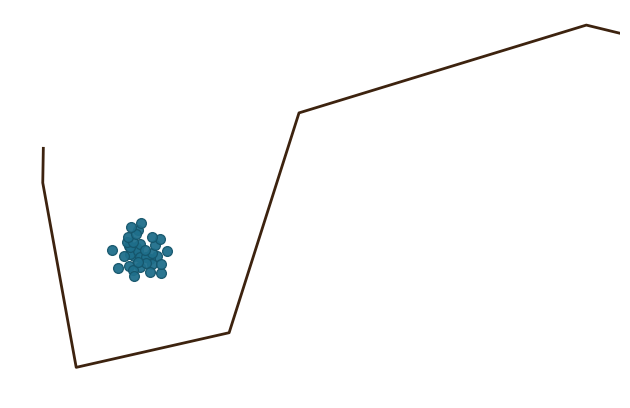

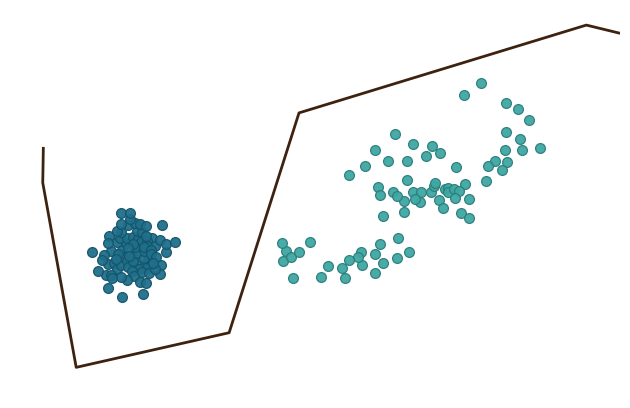

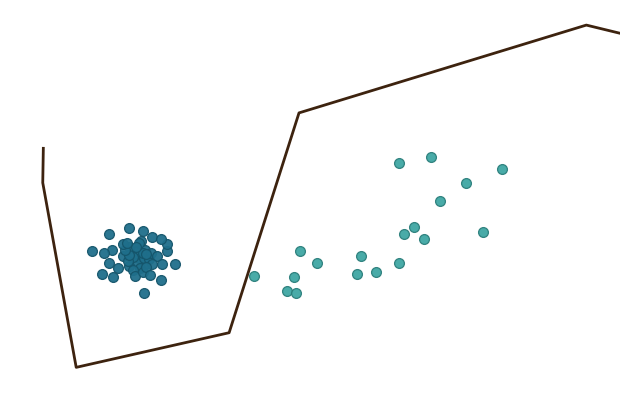

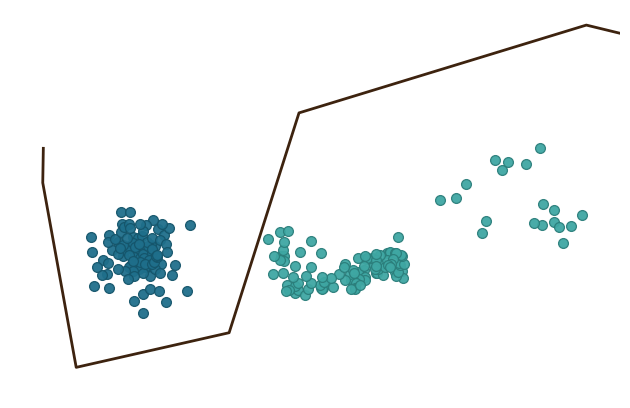

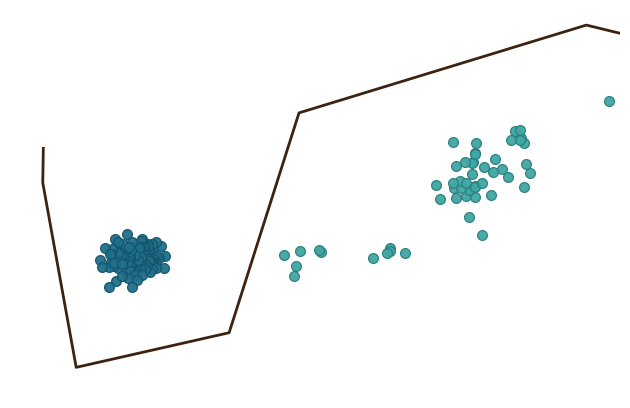

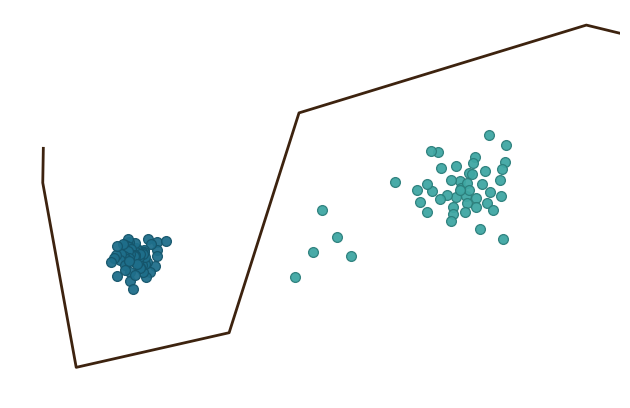

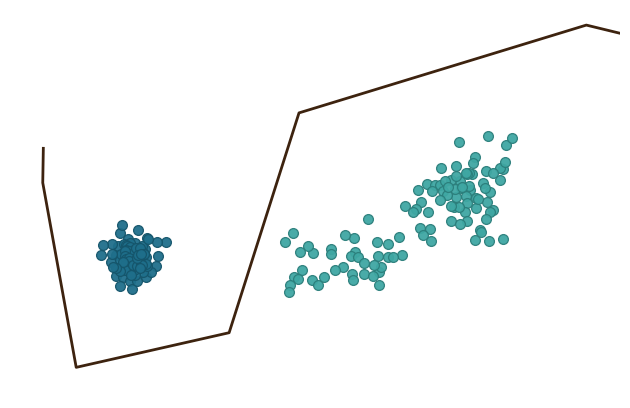

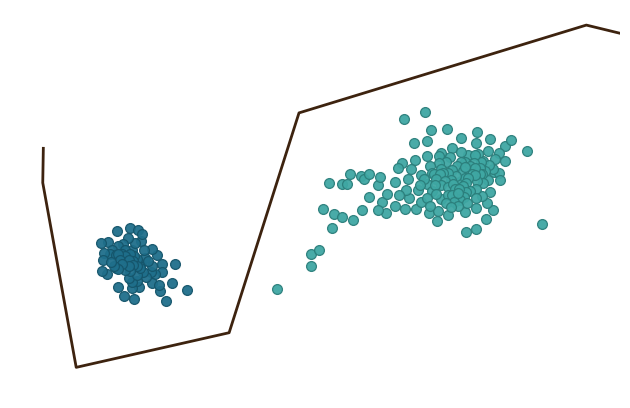

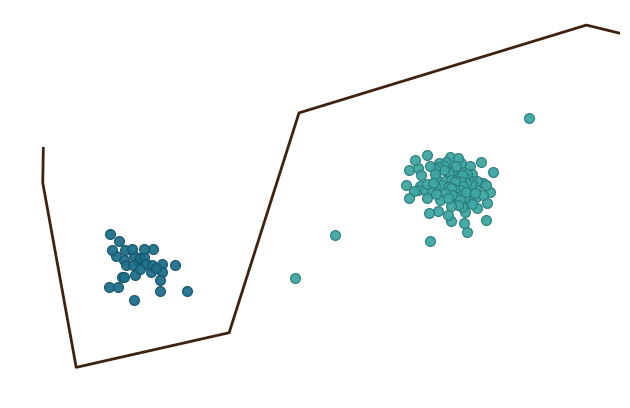

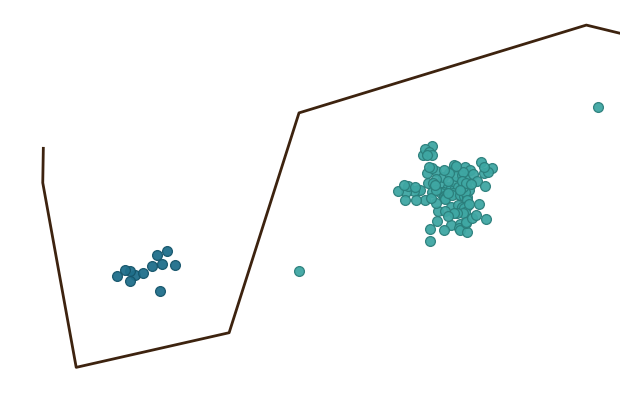

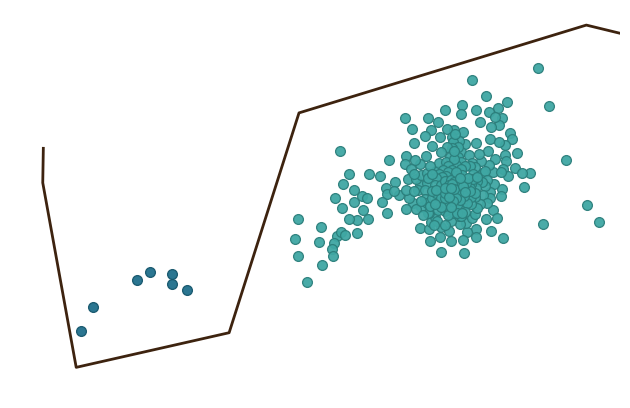

In [8]:
## Load roads and plot one figure per date
roads_gdf = gpd.read_file('rawdata/Velavadar/VelavadarRoads.shp', engine='pyogrio')

## Plot figure
for rec in date_records:
    fig, ax = plt.subplots(1,1)

    roads_gdf.plot(ax=ax, linewidth=2, color='#3D230F', zorder=1)

    if rec['lek1'] is not None:
        ax.scatter(rec['lek1']['longitude'], rec['lek1']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 1'), edgecolor=point_cols.get('Velavadar Lek 1'),
                   linewidth=0.9, alpha=0.95, zorder=3, label='Lek 1')

    if rec['lek2'] is not None:
        ax.scatter(rec['lek2']['longitude'], rec['lek2']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 2'), edgecolor=point_cols.get('Velavadar Lek 2'),
                   linewidth=0.9, alpha=0.95, zorder=4, label='Lek 2')

    ax.set_xlim(72.018,72.04) 
    ax.set_ylim(22.043,22.056)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_dir/f"territories_{rec['date_label']}.png", dpi=300)
    plt.show()

### Model the effect of asocial innovation on the lek site transition

In [9]:
## Preference transition with innovation only
preference_mod = """
data {
  int<lower=1> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;
  
  vector[n_points] logN;
  vector[n_points] dNDVI;
}

parameters {
  real alpha;
  real gamma_NDVI;
  real delta_N;
}

transformed parameters {
  vector[n_points] mu;

  mu[1] = 0.0;
  for (n in 2:n_points) {
    mu[n] = inv_logit(alpha + gamma_NDVI*dNDVI[n-1] + delta_N*logN[n-1]);
  }
}

model {
  alpha ~ normal(0, 1);
  gamma_NDVI ~ normal(0, 1);
  delta_N ~ normal(0, 1);

  y ~ binomial(N, mu);
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  for (n in 1:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [10]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'dNDVI': dNDVI_z.astype(float),
    'N': df['N'].astype(int).to_numpy(),
    'logN': df['logN'].astype(float).to_numpy(),
    'y': df['N2'].astype(int).to_numpy()
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.23 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.15 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.27 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.16 seconds.
  Adjust your expectations accordingly!


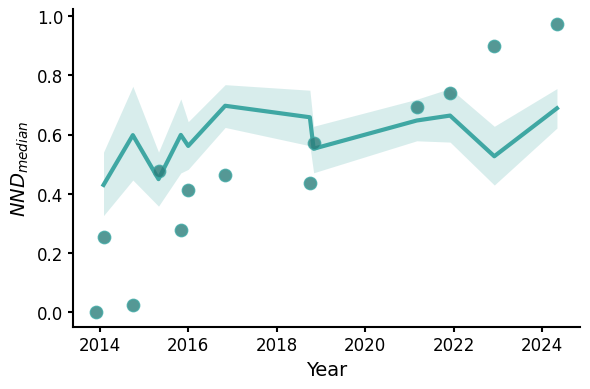

In [11]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(6, 4))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot model fits
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'], df['p2'], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('$NND_{median}$', fontsize=14)

plt.tight_layout()
plt.show()

### Model the total effect of asocial innovation and social learning on the lek site transition

In [12]:
## Preference transition with innovation and unbiased social copying
preference_mod = """
data {
  int<lower=1> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;
  
  vector[n_points] logN;
  vector[n_points] dNDVI;
}

transformed data {
  vector[n_points] p_obs;

  for (n in 1:n_points) {
    p_obs[n] = (y[n] + 0.0) / N[n];
  }
}

parameters {
  real alpha;
  real gamma_NDVI;
  real delta_N;

  real<lower=0, upper=1> eps;
}

transformed parameters {
  vector[n_points] mu;
  mu[1] = fmin(fmax(p_obs[1], 1e-6), 1 - 1e-6);

  for (n in 2:n_points) {
    real innov = inv_logit(alpha + gamma_NDVI * dNDVI[n-1] + delta_N * logN[n-1]);
    real copy  = p_obs[n-1];

    mu[n] = (1 - eps) * copy + eps * innov;
  }
}

model {
  alpha ~ normal(0, 1);
  gamma_NDVI ~ normal(0, 1);
  delta_N ~ normal(0, 1);
  eps ~ beta(2, 2);

  y ~ binomial(N, mu);
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  for (n in 1:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [13]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'dNDVI': dNDVI_z.astype(float),
    'N': df['N'].astype(int).to_numpy(),
    'logN': df['logN'].astype(float).to_numpy(),
    'y': df['N2'].astype(int).to_numpy()
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.18 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.15 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.14 seconds.
  Adjust your expectations accordingly!


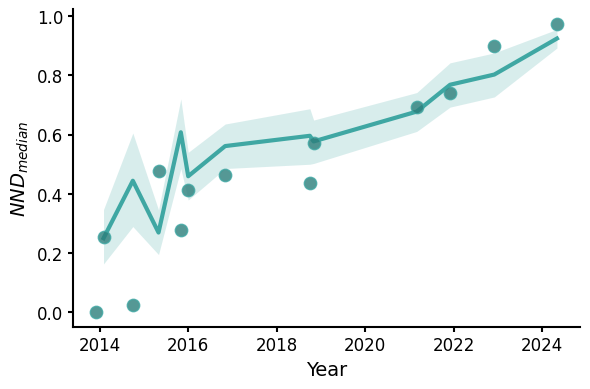

In [14]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(6, 4))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot model fits
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'], df['p2'], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('$NND_{median}$', fontsize=14)

plt.tight_layout()
plt.show()

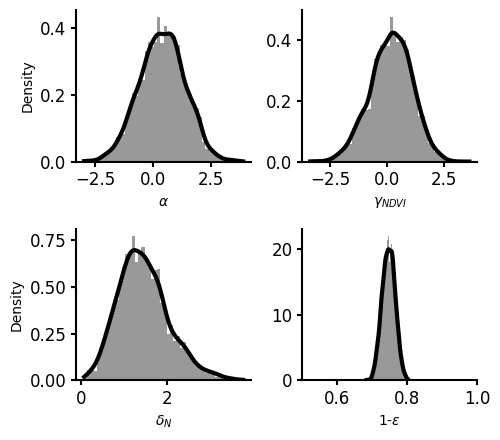

In [15]:
fig,ax = plt.subplots(2,2, figsize=(5,5))

sns.histplot(fit['alpha'].reshape(-1), bins=50, kde=True, stat='density', color='black', line_kws={'linewidth': 3}, edgecolor='none', alpha=0.4, ax=ax[0,0])
sns.histplot(fit['gamma_NDVI'].reshape(-1), bins=50, kde=True, stat='density', color='black', line_kws={'linewidth': 3}, edgecolor='none', alpha=0.4, ax=ax[0,1])
sns.histplot(fit['delta_N'].reshape(-1), bins=50, kde=True, stat='density', color='black', line_kws={'linewidth': 3}, edgecolor='none', alpha=0.4, ax=ax[1,0])
sns.histplot(1-fit['eps'].reshape(-1), bins=50, kde=True, stat='density', color='black', line_kws={'linewidth': 3}, edgecolor='none', alpha=0.4, ax=ax[1,1])

ax[0,0].set_xlabel(r'$\alpha$')
ax[0,1].set_xlabel(r'$\gamma_{NDVI}$')
ax[0,1].set_ylabel('')
ax[1,0].set_xlabel(r'$\delta_{N}$')
ax[1,1].set_xlabel(r'1-$\epsilon$')
ax[1,1].set_ylabel('')
ax[1,1].set_xlim(0.5,1)

for a in ax.flat:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(1.5)
    a.spines['bottom'].set_linewidth(1.5)
    a.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout(rect=[0, 0, 1, 0.90])